## Exploratory Data Analysis (EDA) on Titanic Dataset

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns

In [67]:
df = sns.load_dataset('titanic')
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [68]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### finding Relationships between Features (visualization)

In [70]:
import matplotlib.pyplot as plt


Survival Rate by Pclass:


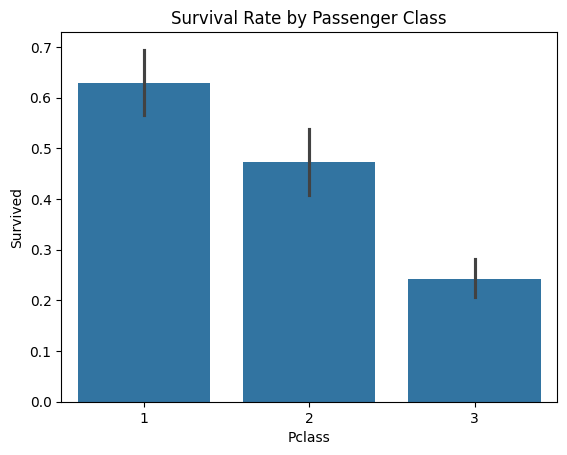

In [71]:
print("\nSurvival Rate by Pclass:")
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.show()

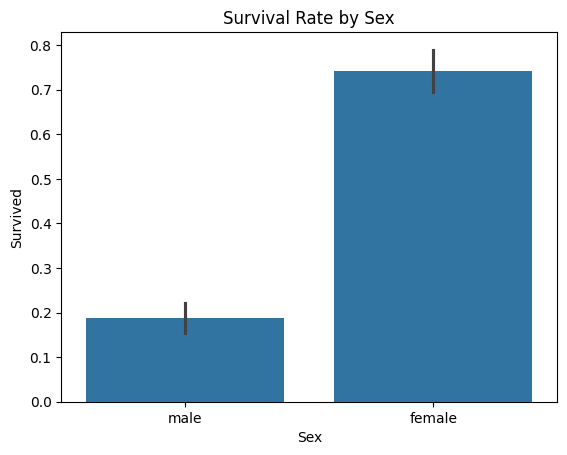

In [72]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()


Survival Rate by Embarked Port:


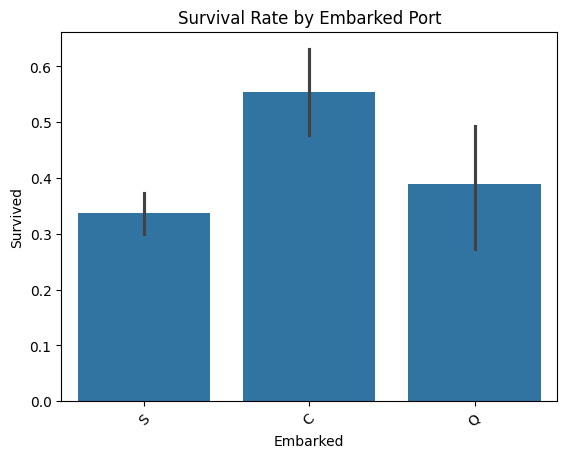

In [73]:
print("\nSurvival Rate by Embarked Port:")
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title('Survival Rate by Embarked Port')
plt.xticks(rotation=45)
plt.show()

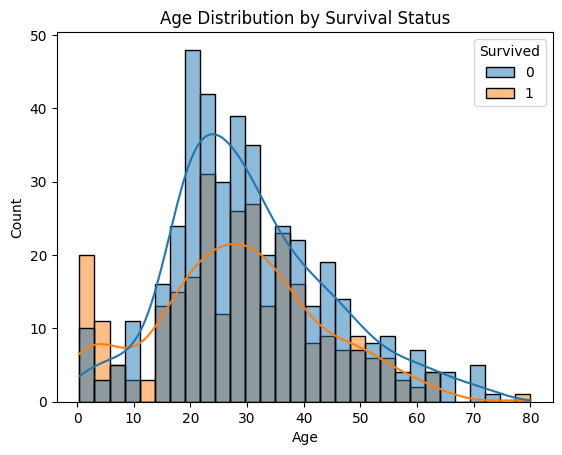

In [74]:
sns.histplot(x='Age', hue='Survived', data=df, kde=True, bins=30)
plt.title('Age Distribution by Survival Status')
plt.show()

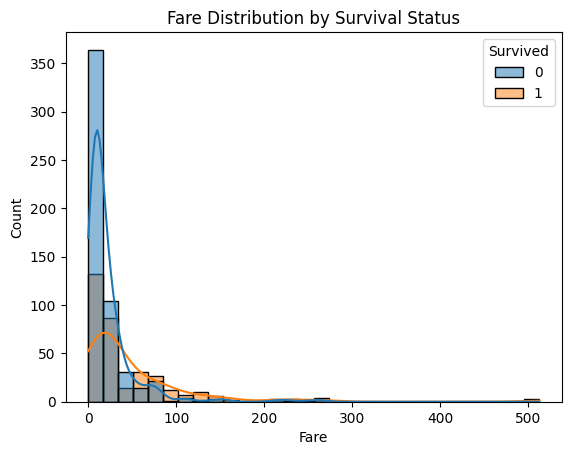

In [75]:
sns.histplot(x='Fare', hue='Survived', data=df, kde=True, bins=30)
plt.title('Fare Distribution by Survival Status')
plt.show()

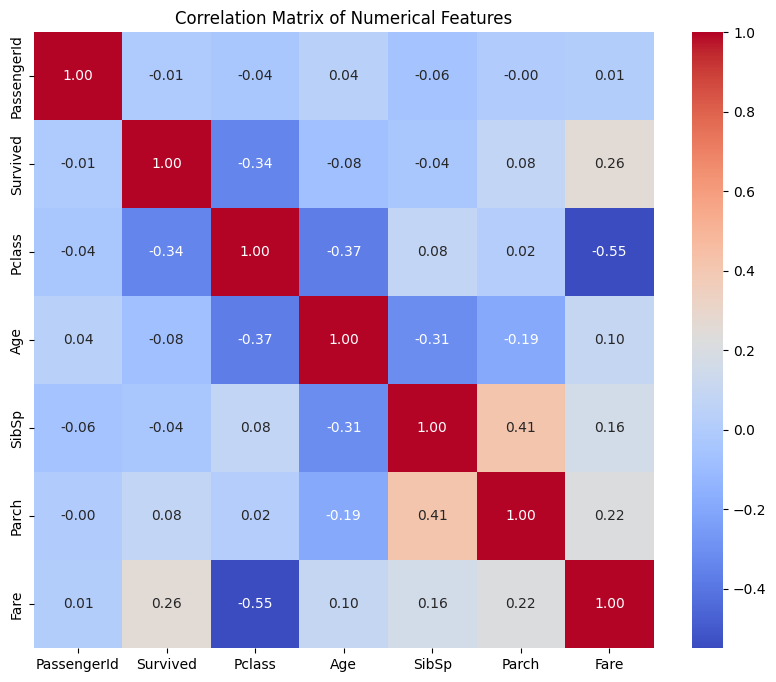

In [76]:
correlation_matrix = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [77]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [78]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Handling Missing Values

In [79]:
# Droping the 'Cabin' column due to a large number of missing values
df_processed = df.drop('Cabin', axis=1)
print("Dropped 'Cabin' column.")

Dropped 'Cabin' column.


In [80]:
# filling age with mean values
df_processed['Age'] = df_processed['Age'].fillna(df_processed['Age'].median())
print("Imputed missing 'Age' values with the median.")

# Impute missing 'Embarked' values with the mode
mode_value = df_processed['Embarked'].mode()[0]
df_processed['Embarked'] = df_processed['Embarked'].fillna(mode_value)
print(f"Imputed missing 'Embarked' values with the mode: {mode_value}.")

Imputed missing 'Age' values with the median.
Imputed missing 'Embarked' values with the mode: S.


In [81]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [82]:
df_processed.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### handling  Duplicates and Outliers

In [83]:
df_processed.shape

(891, 11)

In [84]:
print("Number of duplicate rows before removal:", df_processed.duplicated().sum())

df_processed.drop_duplicates(inplace=True)
print("Number of duplicate rows after removal:", df_processed.duplicated().sum())

print("DataFrame shape after duplicate removal:", df_processed.shape)

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0
DataFrame shape after duplicate removal: (891, 11)


### Feature Engineering

In [86]:
# Creating  a 'FamilySize' feature
df_processed['FamilySize'] = df_processed['SibSp'] + df_processed['Parch'] + 1
print("\n'FamilySize' feature created. Displaying head with new feature:")
display(df_processed[['SibSp', 'Parch', 'FamilySize', 'Survived']].head())


'FamilySize' feature created. Displaying head with new feature:


,SibSp,Parch,FamilySize,Survived
0,1,0,2,0
1,1,0,2,1
2,0,0,1,1
3,1,0,2,1
4,0,0,1,0


In [13]:
# Create an 'IsAlone' feature
df_processed['IsAlone'] = (df_processed['FamilySize'] == 1).astype(int)
print("\n'IsAlone' feature created. Displaying head with new feature:")
display(df_processed[['FamilySize', 'IsAlone', 'survived']].head())


'IsAlone' feature created. Displaying head with new feature:


,FamilySize,IsAlone,survived
0,2,0,0
1,2,0,1
2,1,1,1
3,2,0,1
4,1,1,0


In [88]:
# Create 'AgeGroup' feature
df_processed['AgeGroup'] = pd.cut(df_processed['Age'], bins=[0, 12, 18, 60, 80], labels=['Child', 'Teenager', 'Adult', 'Senior'])
print("\n'AgeGroup' feature created. Displaying head with new feature:")
display(df_processed[['Age', 'AgeGroup', 'Survived']].head())


'AgeGroup' feature created. Displaying head with new feature:


,Age,AgeGroup,Survived
0,22.0,Adult,0
1,38.0,Adult,1
2,26.0,Adult,1
3,35.0,Adult,1
4,35.0,Adult,0


### Outlier Detection

Identifying outliers using Box Plots for numerical features:

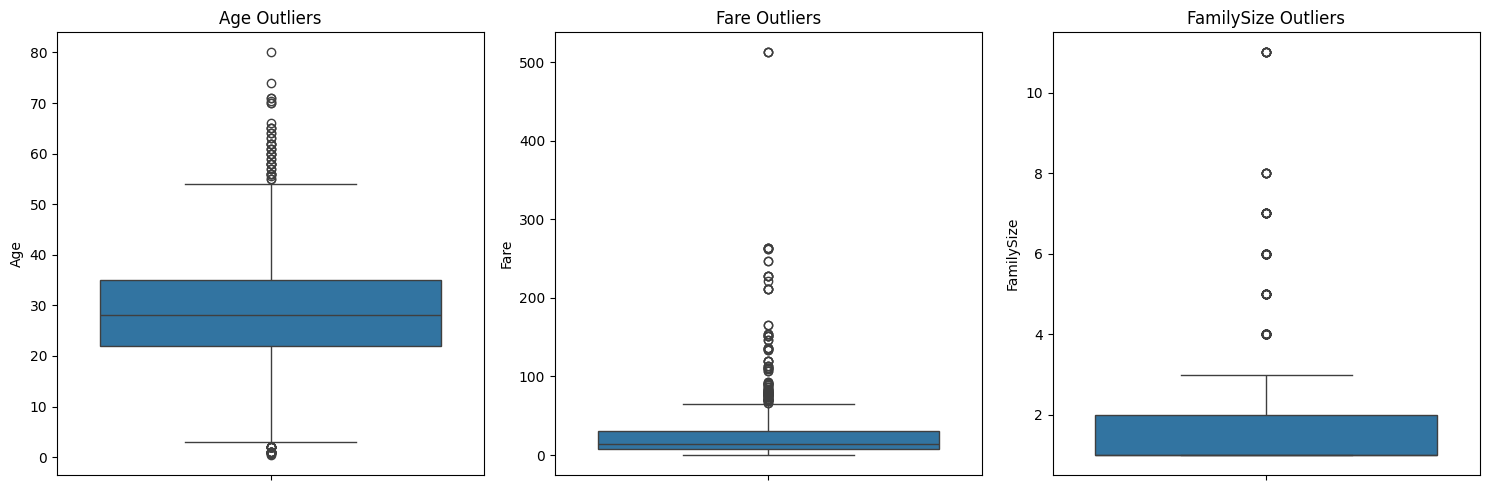


Numerical features with potential outliers:
Column 'Age': 66 outliers detected (Min: 0.42, Max: 80.00)
Column 'Fare': 116 outliers detected (Min: 66.60, Max: 512.33)
Column 'FamilySize': 91 outliers detected (Min: 4.00, Max: 11.00)


In [90]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df_processed['Age'])
plt.title('Age Outliers')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_processed['Fare'])
plt.title('Fare Outliers')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_processed['FamilySize'])
plt.title('FamilySize Outliers')

plt.tight_layout()
plt.show()

print("\nNumerical features with potential outliers:")
for col in ['Age', 'Fare', 'FamilySize']:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_processed[(df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)]
    if not outliers.empty:
        print(f"Column '{col}': {len(outliers)} outliers detected (Min: {outliers[col].min():.2f}, Max: {outliers[col].max():.2f})")
    else:
        print(f"Column '{col}': No significant outliers detected.")

### Data Visualization


Survival Rate Distribution:


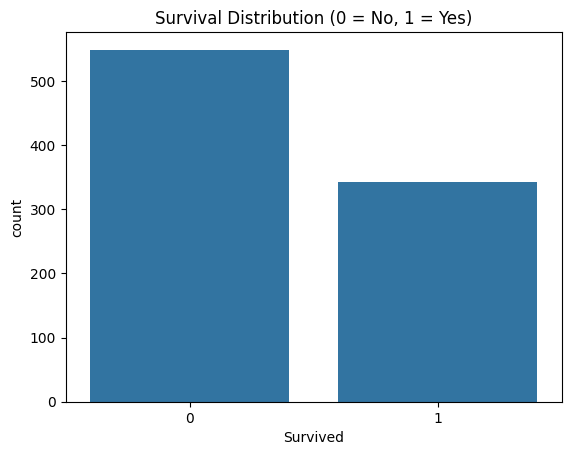

In [92]:
print("\nSurvival Rate Distribution:")
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution (0 = No, 1 = Yes)')
plt.show()


Age Distribution:


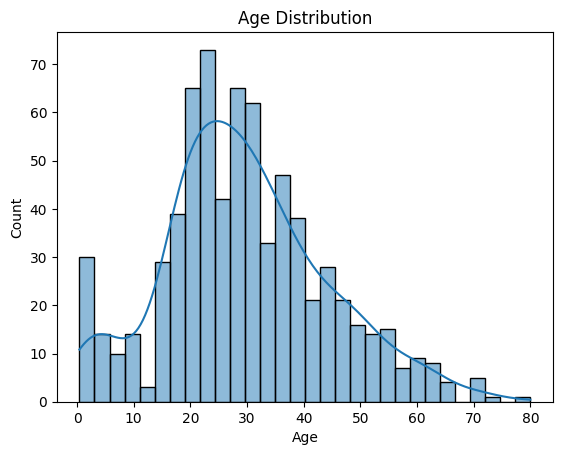

In [93]:
print("\nAge Distribution:")
sns.histplot(df['Age'].dropna(), kde=True, bins=30)
plt.title('Age Distribution')
plt.show()


Fare Distribution:


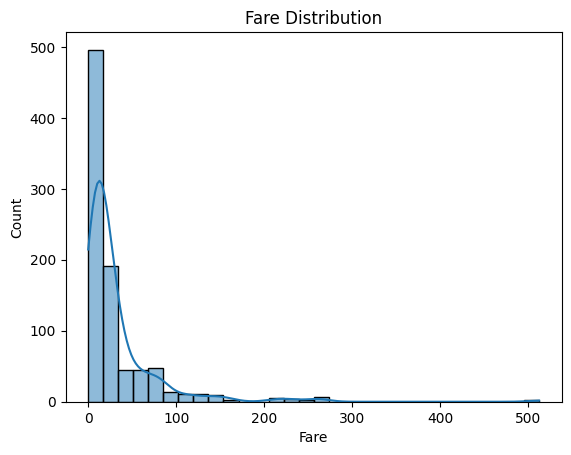

In [94]:
print("\nFare Distribution:")
sns.histplot(df['Fare'], kde=True, bins=30)
plt.title('Fare Distribution')
plt.show()


Passenger Class Distribution:


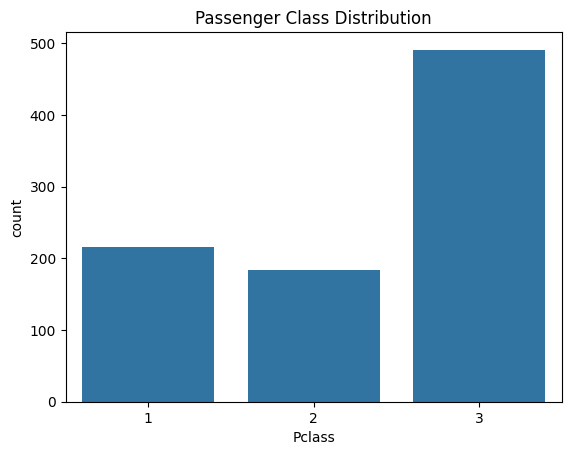

In [95]:
print("\nPassenger Class Distribution:")
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.show()


Gender Distribution:


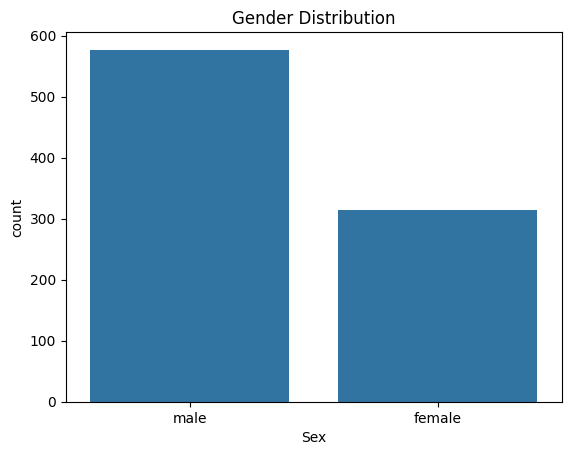

In [96]:
print("\nGender Distribution:")
sns.countplot(x='Sex', data=df)
plt.title('Gender Distribution')
plt.show()


Embarked Port Distribution:


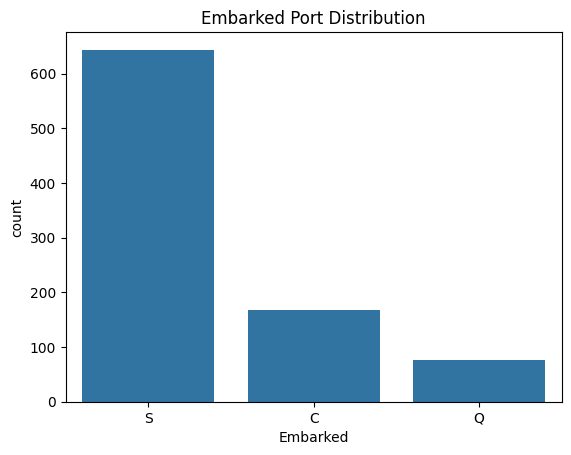

In [97]:
print("\nEmbarked Port Distribution:")
sns.countplot(x='Embarked', data=df)
plt.title('Embarked Port Distribution')
plt.show()